### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
# Ingreso total por tienda
ingresos = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum(),
}

for nombre, total in ingresos.items():
    print(f"{nombre}: ${total:,.0f}")

Tienda 1: $1,150,880,400
Tienda 2: $1,116,343,500
Tienda 3: $1,098,019,600
Tienda 4: $1,038,375,700


# 2. Ventas por categoría

In [3]:
# Ventas por categoría por tienda
tiendas = {"Tienda 1": tienda, "Tienda 2": tienda2, "Tienda 3": tienda3, "Tienda 4": tienda4}

for nombre, df in tiendas.items():
    print(f"\n{nombre}:")
    print(df["Categoría del Producto"].value_counts().to_string())


Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171

Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181

Tienda 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177

Tienda 4:
Categoría del Producto
Muebles                    480
Electrónicos               451
Juguetes                   338
Deportes y diversión       

# 3. Calificación promedio de la tienda


In [4]:
# Calificación promedio por tienda
for nombre, df in tiendas.items():
    promedio = df["Calificación"].mean()
    print(f"{nombre}: {promedio:.2f} / 5")

Tienda 1: 3.98 / 5
Tienda 2: 4.04 / 5
Tienda 3: 4.05 / 5
Tienda 4: 4.00 / 5


# 4. Productos más y menos vendidos

In [5]:
# Producto más y menos vendido por tienda
for nombre, df in tiendas.items():
    conteo = df["Producto"].value_counts()
    print(f"\n{nombre}:")
    print(f"  Más vendido:  {conteo.idxmax()} ({conteo.max()} ventas)")
    print(f"  Menos vendido: {conteo.idxmin()} ({conteo.min()} ventas)")


Tienda 1:
  Más vendido:  Microondas (60 ventas)
  Menos vendido: Auriculares con micrófono (33 ventas)

Tienda 2:
  Más vendido:  Iniciando en programación (65 ventas)
  Menos vendido: Juego de mesa (32 ventas)

Tienda 3:
  Más vendido:  Kit de bancas (57 ventas)
  Menos vendido: Bloques de construcción (35 ventas)

Tienda 4:
  Más vendido:  Cama box (62 ventas)
  Menos vendido: Guitarra eléctrica (33 ventas)


# 5. Envío promedio por tienda

In [6]:
# Costo de envío promedio por tienda
for nombre, df in tiendas.items():
    promedio_envio = df["Costo de envío"].mean()
    print(f"{nombre}: ${promedio_envio:,.0f} promedio de envío")

Tienda 1: $26,019 promedio de envío
Tienda 2: $25,216 promedio de envío
Tienda 3: $24,806 promedio de envío
Tienda 4: $23,459 promedio de envío


# Graficos

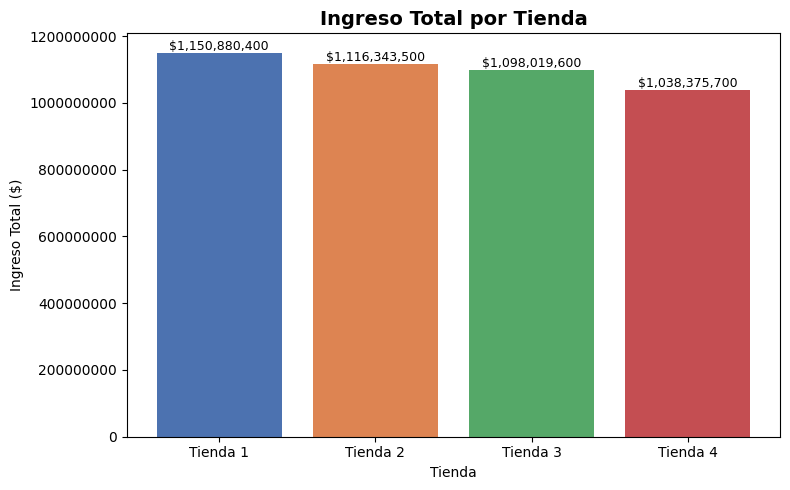

In [7]:
import matplotlib.pyplot as plt

nombres = list(ingresos.keys())
valores = list(ingresos.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(nombres, valores, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Ingreso Total por Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Tienda")
plt.ylabel("Ingreso Total ($)")
plt.ticklabel_format(style="plain", axis="y")

for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f"${val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

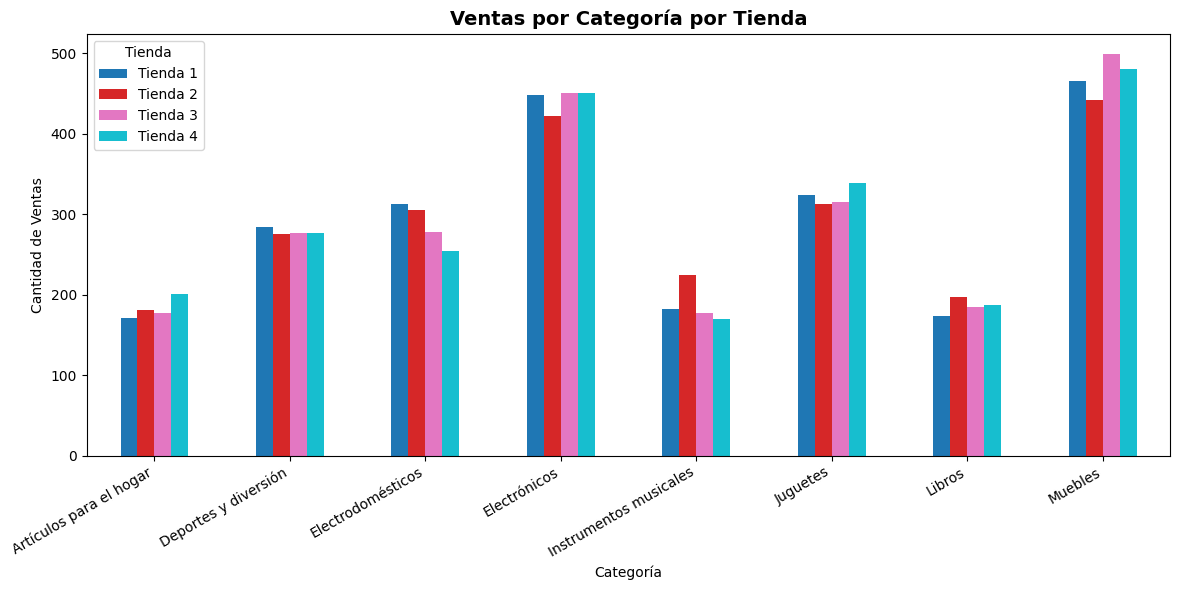

In [8]:
import pandas as pd

# Construir DataFrame consolidado de categorías
cat_data = {}
for nombre, df in tiendas.items():
    cat_data[nombre] = df["Categoría del Producto"].value_counts()

df_categorias = pd.DataFrame(cat_data).fillna(0)

df_categorias.plot(kind="bar", figsize=(12, 6), colormap="tab10")
plt.title("Ventas por Categoría por Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de Ventas")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Tienda")
plt.tight_layout()
plt.show()

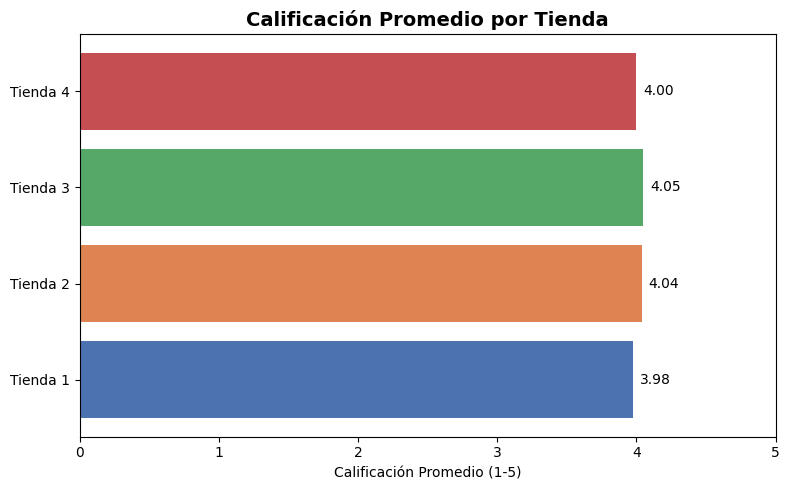

In [9]:
promedios = {nombre: df["Calificación"].mean() for nombre, df in tiendas.items()}

plt.figure(figsize=(8, 5))
bars = plt.barh(list(promedios.keys()), list(promedios.values()),
                color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Calificación Promedio por Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Calificación Promedio (1-5)")
plt.xlim(0, 5)

for bar, val in zip(bars, promedios.values()):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()


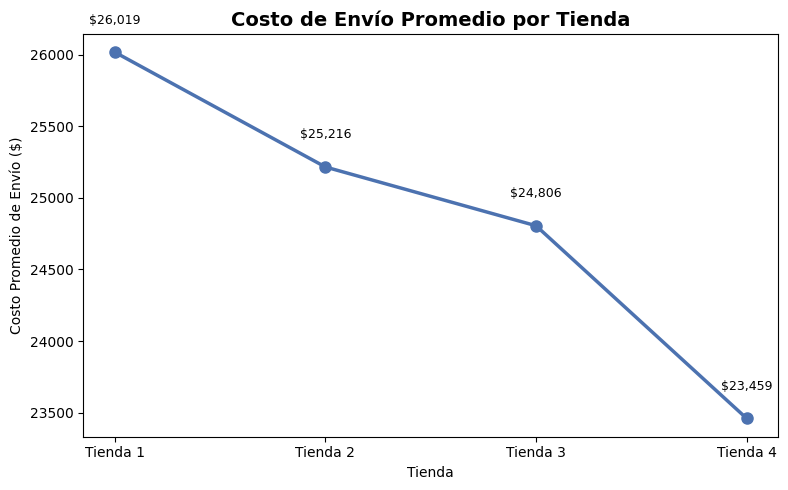

In [10]:
envios = {nombre: df["Costo de envío"].mean() for nombre, df in tiendas.items()}

plt.figure(figsize=(8, 5))
plt.plot(list(envios.keys()), list(envios.values()),
         marker="o", linewidth=2.5, color="#4C72B0", markersize=8)
plt.title("Costo de Envío Promedio por Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Tienda")
plt.ylabel("Costo Promedio de Envío ($)")

for i, (tienda_nombre, val) in enumerate(envios.items()):
    plt.text(i, val + 200, f"${val:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

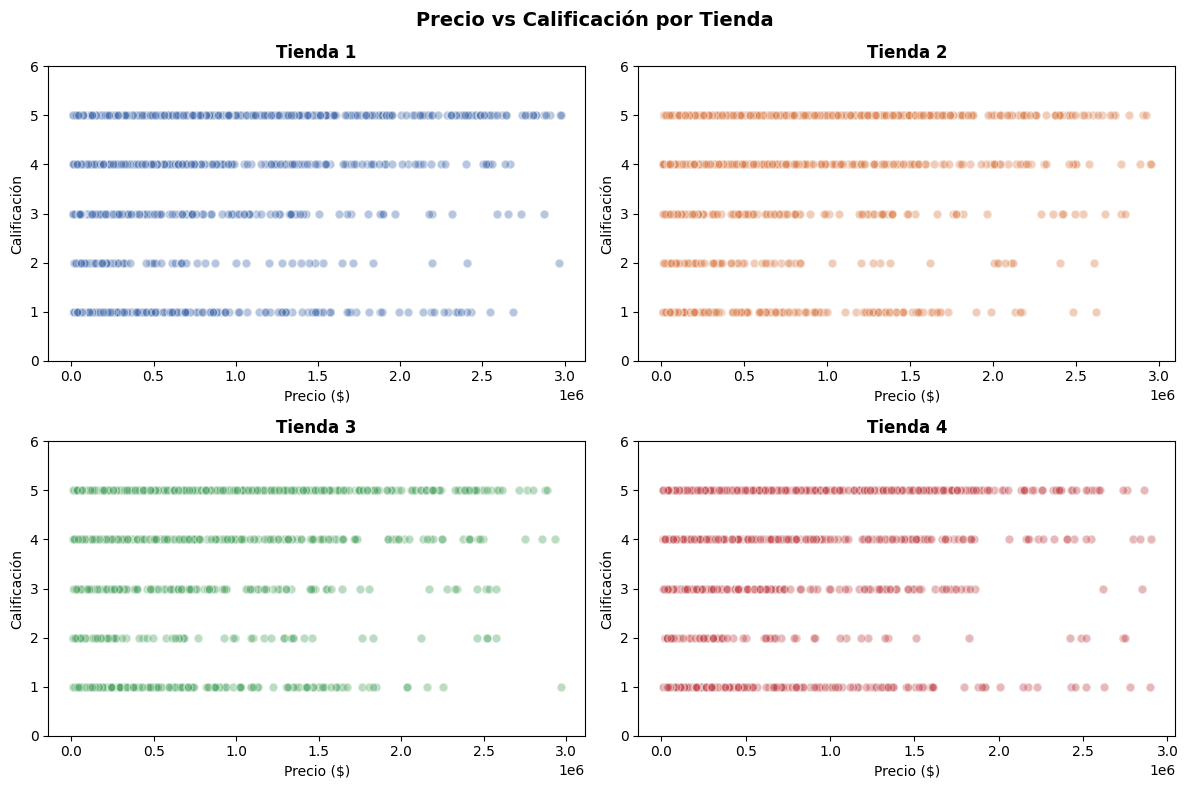

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (nombre, df) in enumerate(tiendas.items()):
    axes[i].scatter(df["Precio"], df["Calificación"],
                    alpha=0.4, color=colores[i], edgecolors="white", s=40)
    axes[i].set_title(nombre, fontweight="bold")
    axes[i].set_xlabel("Precio ($)")
    axes[i].set_ylabel("Calificación")
    axes[i].set_ylim(0, 6)

plt.suptitle("Precio vs Calificación por Tienda", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Informe Final — Análisis de Tiendas Alura Store

## Introducción

Este análisis tiene un objetivo concreto: ayudar al Sr. Juan a decidir cuál de
sus cuatro tiendas debería vender para poder enfocarse en un nuevo proyecto.
Para tomar esa decisión de forma responsable, se revisaron los datos de las cuatro
tiendas desde distintos ángulos: cuánto ingresa cada una, qué venden, cómo las
califican los clientes y cuánto cobran de envío. A continuación se presenta un
resumen de lo que se encontró.

---

## Desarrollo

Al revisar los ingresos totales, la diferencia entre tiendas no es grande,
pero sí es consistente. La Tienda 1 lidera con poco más de 1.150 millones,
mientras que la Tienda 4 queda última con alrededor de 1.038 millones. Una
brecha de más de 112 millones que es una diferencia notoria.

Muebles y Electrónicos dominan las ventas en todas
las tiendas sin excepción, sin embargo la
Tienda 2 se distingue en Instrumentos musicales con un volumen bastante mayor
al de las demás, y la Tienda 3 lidera en Muebles. La Tienda 4, en cambio,
muestra ventas iguales en todas las categorías, No tener un punto fuerte claro es una señal que vale la pena
considerar.

Las calificaciones de los clientes son similares entre tiendas, lo que indica
que en general el servicio es aceptable. La Tienda 3 tiene
el mejor promedio con 4.05, seguida de la Tienda 2 con 4.04. La Tienda 4
queda en 4.00 y la Tienda 1 es la única que no llega a ese puntaje, con 3.98.
Diferencias pequeñas, pero que suman al panorama general.

Sobre el costo de envío, la Tienda 4 es la más económica para el cliente con
un promedio de 23.459, frente a los 26.019 de la Tienda 1. En teoría eso
debería ser una ventaja competitiva, pero en la práctica no se tradujo en
mayores ingresos ni en un volumen de ventas superior. La ventaja existe, pero
no está generando el impacto que debería.

---

## Conclusión

Considerando todo lo analizado, la recomendación es que el Sr. Juan venda la
Tienda 4. Es la que menos ingresos genera, no tiene una categoría donde
sobresalga, y su única ventaja visible, el menor costo de envío, no logró
convertirse en un diferenciador real frente a las otras tiendas. Venderla es
la decisión que tiene más respaldo en los datos, y le permitiría al Sr. Juan
liberar recursos para invertir en su nuevo emprendimiento con una base más
sólida.